## Orchestrator-Worker

In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

**When to use this workflow:** This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")

# llm = ChatOpenAI(model="gpt-4o")

result = llm.invoke("Hello")

result

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.030844071, 'completion_tokens_details': None, 'prompt_time': 0.001730687, 'prompt_tokens_details': None, 'queue_time': 0.049991082, 'total_time': 0.032574758}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea5bd-0bfe-7050-b7be-4cb14fbe298a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [4]:
from typing import Annotated, List
import operator

from typing_extensions import Literal

from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage, SystemMessage

from typing_extensions import TypedDict

In [5]:
# Schema for structured output to use in planning

class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report"
    )
    description: str = Field(
        description="Brief Overview of the main topics and concepts of the section"
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report"
    )


planner = llm.with_structured_output(Sections)

### Create Workers dynamically in langgraph
Because orchestrator-worker workflows are common, LangGraph has the **Send API** to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and **Send** each to a worker node.


In [7]:
from langgraph.types import Send

# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections

    completed_sections: Annotated[
        list,
        operator.add
    ]  # All workers write to this key in parallel

    final_report: str  # Final report

# Worker state

class WorkerState(TypedDict):
    section: Section

    completed_sections: Annotated[
        list,
        operator.add
    ]

In [8]:
# Nodes

def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(
                content=f"Here is the report topic: {state['topic']}"
            ),
        ]
    )

    print("Report Sections:", report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content=(
                    "Write a report section following the provided name and description. Include no preamble for each section. Use Makrdown formatting. "
                )
            ),
            HumanMessage(
                content=(
                    f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
                )
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# Conditional edge function to create llm_call workers that each write a section of the report

def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [
        Send("llm_call", {"section": s}) for s in state["sections"]
    ]

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed sections to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

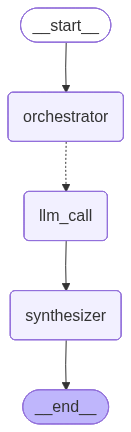

In [9]:
# Build workflow

from langgraph.graph import StateGraph, START, END

orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")

orchestrator_worker_builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["llm_call"]
)

orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow

orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
from IPython.display import display,Image
display(
    Image(
        orchestrator_worker.get_graph().draw_mermaid_png()
    )
)

In [10]:
# Invoke

state = orchestrator_worker.invoke(
    {
        "topic": "Create a report on Agentic AI RAGs"
    }
)

from IPython.display import Markdown

Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction to Agentic AI RAGs', description='Overview of Agentic AI RAGs, definition and significance'), Section(name='Technical Details of Agentic AI RAGs', description='In-depth explanation of the technical aspects of Agentic AI RAGs, including architecture and components'), Section(name='Applications and Use Cases of Agentic AI RAGs', description='Discussion of the various applications and use cases of Agentic AI RAGs, including real-world examples'), Section(name='Challenges and Limitations of Agentic AI RAGs', description='Analysis of the challenges and limitations of Agentic AI RAGs, including potential risks and drawbacks'), Section(name='Future Directions and Potential of Agentic AI RAGs', description='Exploration of the future directions and potential of Agentic AI RAGs, including potential advancements and innovations')]


### Introduction to Agentic AI RAGs
#### Overview of Agentic AI RAGs
Agentic AI RAGs (Retrieval-Augmented Generators) represent a significant advancement in artificial intelligence, combining the capabilities of large language models with external knowledge retrieval mechanisms. This integration enables Agentic AI RAGs to access and incorporate a vast amount of information from various sources, making them highly effective in generating accurate, informative, and contextually relevant responses.

#### Definition
Agentic AI RAGs can be defined as AI systems that leverage both internal knowledge stored within the model and external knowledge retrieved from databases or the internet to generate human-like text or answers. The term "agentic" refers to the ability of these systems to act autonomously, making decisions on what information to retrieve and how to use it in response generation.

#### Significance
The significance of Agentic AI RAGs lies in their potential to revolutionize the field of natural language processing (NLP) and beyond. By enhancing the ability of AI models to understand and generate human-like language, Agentic AI RAGs can be applied in various domains, such as customer service, content creation, language translation, and education. Their capacity to access and utilize external knowledge makes them particularly useful for tasks that require up-to-date information or specialized knowledge, positioning them as a key technology for future AI development.

---

### Technical Details of Agentic AI RAGs
#### Architecture
The architecture of Agentic AI RAGs (Retrieval-Augmented Generation) is based on a combination of natural language processing (NLP) and information retrieval (IR) techniques. It consists of three main components:
* **Retriever**: responsible for fetching relevant information from a large corpus of text, such as a knowledge graph or a database.
* **Reader**: processes the retrieved information to extract relevant context and generate answers or responses.
* **Generator**: uses the extracted context to generate human-like text based on the input prompt.

#### Components
The key components of Agentic AI RAGs include:
* **Knowledge Corpus**: a large database of text that serves as the foundation for the retriever to fetch information from.
* **Embeddings**: used to represent words, phrases, and documents as dense vectors in a high-dimensional space, enabling semantic search and retrieval.
* **Retrieval Algorithms**: such as BM25, TF-IDF, or dense retrieval methods like DPR, that are used to retrieve relevant information from the knowledge corpus.
* **Transformer-based Architectures**: used in the reader and generator components to process and generate text, such as BERT, RoBERTa, or T5.
* **Training Objectives**: a combination of masked language modeling, next sentence prediction, and retrieval-based objectives that are used to train the model end-to-end.

#### Technical Challenges
Agentic AI RAGs pose several technical challenges, including:
* **Scalability**: retrieving and processing large amounts of information from the knowledge corpus can be computationally expensive.
* **Efficient Retrieval**: developing efficient retrieval algorithms that can handle large corpora and retrieve relevant information quickly.
* **Contextual Understanding**: extracting relevant context from the retrieved information and using it to generate coherent and accurate text.
* **Evaluation Metrics**: developing evaluation metrics that can accurately measure the performance of Agentic AI RAGs in terms of accuracy, fluency, and coherence.

---

### Applications and Use Cases of Agentic AI RAGs
Agentic AI RAGs (Retrieval-Augmented Generation) have numerous applications and use cases across various industries, including:
* **Natural Language Processing (NLP)**: Agentic AI RAGs can be used for text summarization, question answering, and language translation, enabling more accurate and efficient processing of human language.
* **Content Generation**: RAGs can generate high-quality content, such as articles, stories, and dialogues, making them useful for applications like content creation, chatbots, and virtual assistants.
* **Decision Support Systems**: By integrating Agentic AI RAGs with decision support systems, organizations can provide users with more informed and personalized recommendations, leading to better decision-making.
* **Education and Training**: RAGs can be used to create personalized learning materials, such as customized textbooks, tutorials, and assessments, tailored to individual students' needs and learning styles.
* **Customer Service**: Agentic AI RAGs can power customer service chatbots, enabling them to provide more accurate and helpful responses to customer inquiries, improving customer satisfaction and reducing support costs.

Real-world examples of Agentic AI RAGs in action include:
* **Virtual writing assistants**: Companies like Microsoft and Google are using RAGs to develop virtual writing assistants that can help users with writing tasks, such as suggesting alternative phrases or completing sentences.
* **Intelligent chatbots**: Organizations like IBM and Salesforce are leveraging RAGs to build more sophisticated chatbots that can understand and respond to customer inquiries more effectively.
* **Personalized content recommendation**: Media companies like Netflix and Spotify are using RAGs to generate personalized content recommendations for their users, improving user engagement and retention.
* **Language translation**: Translation services like Google Translate are utilizing RAGs to improve the accuracy and fluency of their translations, breaking down language barriers and enabling more effective communication across languages and cultures.

---

### Challenges and Limitations of Agentic AI RAGs
#### Technical Challenges
Agentic AI RAGs face several technical challenges, including:
* **Scalability**: As the size of the knowledge graph increases, the computational requirements for querying and updating the graph also increase, making it challenging to scale.
* **Knowledge Graph Maintenance**: Maintaining the accuracy and consistency of the knowledge graph is a significant challenge, especially when dealing with large amounts of data.
* **Query Complexity**: The complexity of queries can increase exponentially with the size of the knowledge graph, making it challenging to optimize query performance.

#### Social and Ethical Challenges
Agentic AI RAGs also raise several social and ethical concerns, including:
* **Bias and Fairness**: The knowledge graph may reflect biases present in the data used to train it, which can lead to unfair outcomes.
* **Transparency and Explainability**: The decision-making process of Agentic AI RAGs can be complex and difficult to interpret, making it challenging to understand the reasoning behind the recommendations.
* **Accountability**: As Agentic AI RAGs become more autonomous, it can be challenging to determine who is accountable for their actions.

#### Potential Risks and Drawbacks
The use of Agentic AI RAGs also carries several potential risks and drawbacks, including:
* **Job Displacement**: The automation of tasks using Agentic AI RAGs can lead to job displacement, particularly in industries where tasks are repetitive or can be easily automated.
* **Dependence on Technology**: The reliance on Agentic AI RAGs can lead to a loss of traditional skills and a dependence on technology, which can be problematic if the technology fails or is unavailable.
* **Cybersecurity Risks**: Agentic AI RAGs can be vulnerable to cybersecurity threats, such as data breaches or hacking, which can compromise the integrity of the knowledge graph and the recommendations provided.

---

### Future Directions and Potential of Agentic AI RAGs
The future of Agentic AI RAGs holds tremendous potential for growth and innovation, with several avenues for exploration and development. 
#### Potential Advancements
* **Improved Decision-Making**: Future Agentic AI RAGs may incorporate more sophisticated decision-making algorithms, enabling them to make more informed and nuanced decisions in complex environments.
* **Enhanced Autonomy**: Advancements in autonomy could allow Agentic AI RAGs to operate with greater independence, requiring less human oversight and intervention.
* **Increased Adaptability**: Next-generation Agentic AI RAGs may be designed to adapt more effectively to changing circumstances, enabling them to respond to unexpected events and challenges.
#### Potential Innovations
* **Multi-Agent Systems**: The development of multi-agent systems, where multiple Agentic AI RAGs interact and cooperate, could lead to significant breakthroughs in areas such as distributed problem-solving and collective intelligence.
* **Human-AI Collaboration**: Innovations in human-AI collaboration could enable Agentic AI RAGs to work more effectively with humans, leading to improved outcomes in areas such as healthcare, finance, and education.
* **Explainable AI**: The integration of explainable AI techniques into Agentic AI RAGs could provide greater transparency and understanding of their decision-making processes, helping to build trust and confidence in these systems.
#### Potential Applications
* **Autonomous Robotics**: Agentic AI RAGs could be used to control and navigate autonomous robots, enabling them to perform complex tasks in areas such as manufacturing, logistics, and search and rescue.
* **Smart Cities**: The deployment of Agentic AI RAGs in smart city infrastructure could optimize energy consumption, traffic flow, and public services, leading to more efficient and sustainable urban environments.
* **Cybersecurity**: Agentic AI RAGs could be used to detect and respond to cyber threats, providing more effective and proactive defenses against malicious actors.